# Crawling Berita Detik.com: Sport dan Finance

Notebook ini membahas proses **Web Search & Mining** menggunakan pendekatan **CRISP-DM** (hingga tahap *Data Preparation*) untuk mengumpulkan dan menganalisis berita dari detik.com. Dataset yang dihasilkan digunakan untuk membandingkan karakteristik berita kategori **sport** dan **finance**.

---

## Business Understanding

### Latar Belakang

Berita online terus bertambah jumlah dan topiknya setiap hari. Pengelompokan berita berdasarkan kategori sangat berguna untuk:
- memudahkan pencarian dan pengarsipan informasi,
- menganalisis tren topik dari waktu ke waktu, dan
- membangun sistem rekomendasi atau klasifikasi berita secara otomatis.

### Tujuan

Mengumpulkan dataset berita berbahasa Indonesia langsung dari situs detik.com, terdiri dari dua kategori:

| Kategori | Sumber | Jumlah |
| --- | --- | --- |
| `sport` | [detikSport](https://sport.detik.com/) | 100 artikel |
| `finance` | [detikFinance](https://finance.detik.com/) | 100 artikel |

Setiap artikel disimpan dengan kolom `id`, `isi_berita`, `label`, dan `url`.

### Pertanyaan yang Ingin Dijawab

1. Apakah data berita dari kategori sport dan finance dapat dikumpulkan secara seimbang?
2. Seperti apa perbedaan panjang isi berita pada kedua kategori?
3. Kata atau topik apa yang paling sering muncul pada masing-masing kategori?
4. Apakah dataset sudah cukup bersih dan lengkap untuk digunakan pada tahap analisis berikutnya?

### Kriteria Keberhasilan

Proses crawling dianggap berhasil apabila:

- tersedia **200 artikel unik** (tidak ada duplikat URL maupun isi berita);
- terdapat tepat **100 artikel** berlabel `sport` dan **100 artikel** berlabel `finance`;
- setiap baris memiliki `id`, isi berita, label, dan URL yang lengkap;
- isi artikel sudah dipisahkan dari navigasi, iklan, dan elemen HTML yang tidak diperlukan.

---

## Data Understanding

### Proses Crawling

**Detail teknis crawling:**
- Halaman indeks yang dikunjungi: hingga 20 halaman per kategori
  (`https://sport.detik.com/indeks?page=N` dan `https://finance.detik.com/indeks?page=N`)
- Link valid: URL yang mengandung pola `/d-<angka>` dan berasal dari domain yang sesuai
- Elemen yang dibuang dari isi artikel: `<script>`, `<style>`, `<aside>`, `<iframe>`, `<figure>`, iklan, dan media
- ID artikel: `SP001`–`SP100` untuk sport, `FN001`–`FN100` untuk finance
- Jeda antar request: 1 detik (menghormati server)

> **Catatan:** Sel crawling di notebook ini dinonaktifkan. Untuk menjalankan ulang crawling, gunakan notebook `01_crawling.ipynb`.

### Struktur Dataset

Hasil crawling disimpan di `dataset_detik.csv` dengan empat kolom:

| Kolom | Tipe | Keterangan |
| --- | --- | --- |
| `id` | string | Identitas unik artikel: `SP001`–`SP100` (sport) atau `FN001`–`FN100` (finance) |
| `isi_berita` | text | Judul dan isi utama artikel yang sudah dibersihkan dari HTML |
| `label` | category | Kategori berita: `sport` atau `finance` |
| `url` | string | URL lengkap artikel dari detik.com |

### Pemeriksaan Awal

Pemeriksaan awal meliputi: jumlah data, distribusi label, nilai kosong, URL duplikat, duplikat isi berita, panjang teks, serta contoh isi artikel. Hasil pemeriksaan dan grafik ditampilkan pada sel-sel berikut.


In [1]:
%pip install pandas requests beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


> **Catatan:** Jalankan sel-sel crawling di bawah ini secara manual jika diperlukan pembaruan dataset. Saat eksekusi otomatis (misal `jupyter nbconvert --execute`), sel ini direkomendasikan untuk dilewati agar tidak memicu request berulang ke server.


In [2]:
import re, time
import requests
import pandas as pd
from bs4 import BeautifulSoup

HEADERS = {"User-Agent": "Mozilla/5.0"}
TARGET = 100
SITUS = {"sport": "sport.detik.com", "finance": "finance.detik.com"}

def buka(url):
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    return BeautifulSoup(r.text, "html.parser")

### 1. Kumpulkan link artikel dari halaman indeks
Link artikel detik selalu mengandung pola `/d-<angka>`.

In [3]:
def ambil_link(domain):
    link = []

    for page in range(1, 21):
        for a in buka(f"https://{domain}/indeks?page={page}").select("a[href]"):
            url = a["href"].split("?")[0]

            if url.startswith(f"https://{domain}") and re.search(r"/d-\d+", url) and url not in link:
                link.append(url)

        if len(link) >= TARGET * 1.5:
            break

        time.sleep(1)

    return link

### 2. Ambil judul + isi satu artikel
Elemen tidak relevan (script, iklan, gambar) dibuang, lalu spasi dirapikan.

In [4]:
def ambil_isi(url):
    soup = buka(url)
    judul = soup.select_one("h1")
    isi = soup.select_one(".detail__body-text, .detail__body, .itp_bodycontent, article")
    if isi is None:
        return ""
    for x in isi.select("script, style, aside, iframe, figure, .detail__media, .parallax, .ad-container"):
        x.decompose()
    teks = " ".join(isi.get_text(" ", strip=True).split())
    judul = judul.get_text(" ", strip=True) if judul else ""
    return f"{judul}. {teks}" if judul and judul.lower() not in teks.lower() else teks

### 3. Crawling semua kategori
Artikel dengan isi < 200 karakter dilewati. ID: `SP001`-`SP100` dan `FN001`-`FN100`.

In [5]:
baris = []
for label, domain in SITUS.items():
    n = 0
    for url in ambil_link(domain):
        try:
            teks = ambil_isi(url)
        except requests.RequestException:
            continue
        if len(teks) < 200:
            continue
        n += 1
        baris.append({"id": ("SP" if label == "sport" else "FN") + f"{n:03d}",
                      "isi_berita": teks, "label": label, "url": url})
        time.sleep(1)
        if n == TARGET:
            break
    print(label, n, "artikel")

df = pd.DataFrame(baris)
df.to_csv("dataset_detik.csv", index=False, encoding="utf-8-sig")
df.head()

sport 100 artikel
finance 100 artikel


,id,isi_berita,label,url
0,SP001,"FIA Rallycross World Cup Hadir di Ancol, Ini K...",sport,https://sport.detik.com/sportstyle/d-8686174/f...
1,SP002,Ini Kunci Desak Made Rita Raih Emas Asian Game...,sport,https://sport.detik.com/sport-lain/d-8686789/i...
2,SP003,Desak Made Raih Emas Panjat Tebing Asian Games...,sport,https://sport.detik.com/fotosport/d-8686774/de...
3,SP004,Profil Desak Made Peraih Emas Keempat RI: Kena...,sport,https://sport.detik.com/sport-lain/d-8686722/p...
4,SP005,"Gacor di Asian Games, Leo/Daniel Kini Bidik Tu...",sport,https://sport.detik.com/raket/d-8686185/gacor-...


In [6]:
print(df["label"].value_counts())
print("URL duplikat:", df["url"].duplicated().sum())

label
sport      100
finance    100
Name: count, dtype: int64
URL duplikat: 0


## Memuat Dataset dan Pemeriksaan Awal

Dataset hasil crawling (`dataset_detik.csv`) dimuat ke dalam DataFrame untuk diperiksa kelengkapan dan konsistensinya sebelum dilanjutkan ke tahap analisis.

**Pemeriksaan yang dilakukan:**
- Jumlah baris dan tipe data tiap kolom (`dataset.info()`)
- Distribusi label `sport` vs `finance`
- Deteksi duplikat URL dan duplikat isi berita
- Tampilan sepuluh baris pertama
- Validasi otomatis dengan `assert` untuk memastikan semua kriteria terpenuhi


In [7]:
import pandas as pd
from IPython.display import display

dataset = pd.read_csv("dataset_detik.csv")
dataset.info()
display(dataset["label"].value_counts().rename_axis("label").to_frame("jumlah"))

dataset["panjang_teks"] = dataset["isi_berita"].str.len()
print("Duplikat URL:", dataset["url"].duplicated().sum())
print("Duplikat isi berita:", dataset["isi_berita"].duplicated().sum())
display(dataset[["id", "label", "url", "isi_berita"]].head(10))

assert set(dataset.columns) == {"id", "isi_berita", "label", "url", "panjang_teks"}
assert dataset["url"].is_unique
assert dataset["isi_berita"].notna().all()
assert dataset["url"].str.startswith("http").all()
assert dataset["label"].value_counts().to_dict() == {"sport": 100, "finance": 100}, (
    "Target belum terpenuhi. Tambahkan halaman sumber pada SOURCES atau ulangi crawling."
)
print("Validasi berhasil: 200 artikel unik, 100 sport, 100 finance.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    object
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
 3   url         200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB


,jumlah
label,
sport,100
finance,100


Duplikat URL: 0
Duplikat isi berita: 0


,id,label,url,isi_berita
0,SP001,sport,https://sport.detik.com/sportstyle/d-8686174/f...,"FIA Rallycross World Cup Hadir di Ancol, Ini K..."
1,SP002,sport,https://sport.detik.com/sport-lain/d-8686789/i...,Ini Kunci Desak Made Rita Raih Emas Asian Game...
2,SP003,sport,https://sport.detik.com/fotosport/d-8686774/de...,Desak Made Raih Emas Panjat Tebing Asian Games...
3,SP004,sport,https://sport.detik.com/sport-lain/d-8686722/p...,Profil Desak Made Peraih Emas Keempat RI: Kena...
4,SP005,sport,https://sport.detik.com/raket/d-8686185/gacor-...,"Gacor di Asian Games, Leo/Daniel Kini Bidik Tu..."
5,SP006,sport,https://sport.detik.com/sport-lain/d-8686648/a...,Asian Games 2026: Desak Made Raih Emas Keempat...
6,SP007,sport,https://sport.detik.com/sport-lain/d-8686152/p...,"Panjat Tebing Buru Medali, Yenni Wahid: Aditya..."
7,SP008,sport,https://sport.detik.com/sportstyle/d-8686158/m...,Mau Nonton FIA Rallycross World Cup Indonesia?...
8,SP009,sport,https://sport.detik.com/sport-lain/d-8686395/o...,"Olahraga yang Digandrungi Gen Z, dari Lari hin..."
9,SP010,sport,https://sport.detik.com/sport-lain/d-8686257/b...,Bintang/Sofyan Tantang Tuan Rumah Jepang di Se...


Validasi berhasil: 200 artikel unik, 100 sport, 100 finance.


Statistik panjang isi berita:


,jumlah,rata_rata,median,minimum,maksimum
label,,,,,
finance,100,2862.0,2818.0,392,6836
sport,100,2535.0,2366.0,443,6331


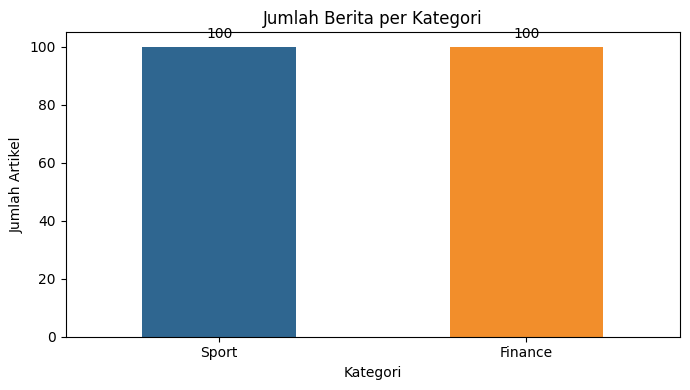

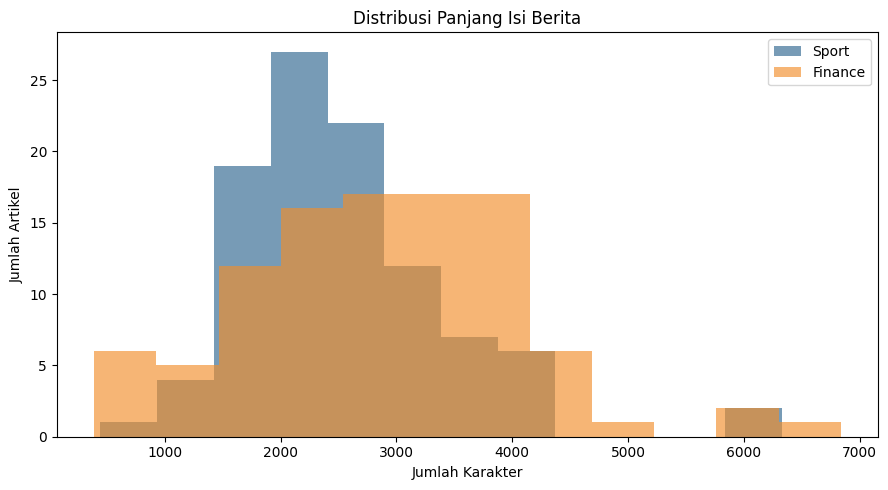

<Figure size 700x400 with 0 Axes>

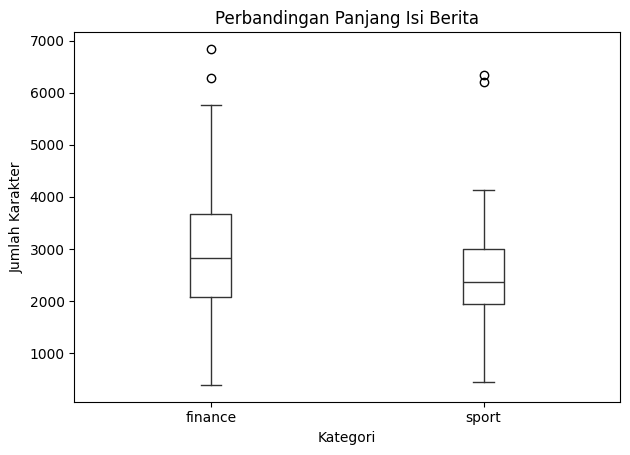

Kata yang paling sering muncul setelah stopword removal:


,sport,finance
games,513,0
asian,506,0
indonesia,496,143
emas,334,0
medali,287,0
leo,252,0
daniel,247,0
menjadi,170,133
wib,160,114
final,154,0


In [8]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Ringkasan statistik panjang teks per kategori.
ringkasan_teks = dataset.groupby("label")["panjang_teks"].agg(
    jumlah="count",
    rata_rata="mean",
    median="median",
    minimum="min",
    maksimum="max",
).round(0)
print("Statistik panjang isi berita:")
display(ringkasan_teks)

# Grafik 1: jumlah artikel pada setiap label.
jumlah_label = dataset["label"].value_counts().reindex(["sport", "finance"])
plt.figure(figsize=(7, 4))
ax = jumlah_label.plot(kind="bar", color=["#2f6690", "#f28e2b"])
ax.set_title("Jumlah Berita per Kategori")
ax.set_xlabel("Kategori")
ax.set_ylabel("Jumlah Artikel")
ax.set_xticklabels(["Sport", "Finance"], rotation=0)
for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height())}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", xytext=(0, 4), textcoords="offset points",
    )
plt.tight_layout()
plt.show()

# Grafik 2: distribusi panjang isi berita.
plt.figure(figsize=(9, 5))
for label, color in [("sport", "#2f6690"), ("finance", "#f28e2b")]:
    plt.hist(
        dataset.loc[dataset["label"] == label, "panjang_teks"],
        bins=12,
        alpha=0.65,
        label=label.title(),
        color=color,
    )
plt.title("Distribusi Panjang Isi Berita")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Jumlah Artikel")
plt.legend()
plt.tight_layout()
plt.show()

# Grafik 3: boxplot untuk membandingkan panjang teks antar kategori.
plt.figure(figsize=(7, 4))
dataset.boxplot(column="panjang_teks", by="label", grid=False, color="#333333")
plt.suptitle("")
plt.title("Perbandingan Panjang Isi Berita")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Karakter")
plt.tight_layout()
plt.show()

# Tabel kata yang sering muncul sebagai gambaran topik awal.
stopwords_id = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan",
    "pada", "dalam", "atau", "juga", "akan", "ada", "sebagai", "lebih",
    "sudah", "telah", "tidak", "karena", "oleh", "saat", "hingga", "dapat",
    "bisa", "jadi", "para", "nya", "ia", "tak", "tersebut", "mereka",
    "tautan", "disalin", "artikel", "baca", "saya", "selengkapnya", "detik",
}


def kata_teratas(label, jumlah=10):
    teks = dataset.loc[dataset["label"] == label, "isi_berita"].str.lower()
    kata = re.findall(r"[a-zA-Z]{3,}", " ".join(teks))
    kata = [item for item in kata if item not in stopwords_id]
    return Counter(kata).most_common(jumlah)


frekuensi_kata = pd.DataFrame({
    "sport": dict(kata_teratas("sport")),
    "finance": dict(kata_teratas("finance")),
}).fillna(0).astype(int)
print("Kata yang paling sering muncul setelah stopword removal:")
display(frekuensi_kata.sort_values(["sport", "finance"], ascending=False).head(10))

## Preprocessing Teks dan Perhitungan Kata Unik

Sebelum data dapat dianalisis lebih lanjut, teks mentah perlu diproses agar seragam dan bersih. Tahap ini meliputi:

1. **Tokenisasi** — memecah teks panjang menjadi kata-kata kecil (*token*).
2. **Lowercase** — mengubah semua huruf menjadi huruf kecil agar `Harga` dan `harga` dihitung sebagai kata yang sama.
3. **Penghapusan simbol** — karakter selain huruf (angka, tanda baca, dll.) dibuang.
4. **Stopword removal** — kata-kata umum seperti `dan`, `di`, `ke`, yang tidak membawa makna khas, dihapus dari daftar token.
5. **Stemming** *(opsional)* — mengubah kata ke bentuk dasarnya menggunakan Sastrawi. Dinonaktifkan secara default (`USE_STEMMING = False`).

**Output yang dihasilkan:**
- Ringkasan kosakata **sebelum** dan **sesudah** stopword removal (jumlah token dan kata unik per label)
- 10 kata yang paling sering muncul di seluruh artikel setelah stopword removal


In [9]:
import sys
print(sys.executable)

d:\data aplikasi\Python311\python.exe


In [10]:
%pip install Sastrawi

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Setup Sastrawi Stemmer (opsional: ubah USE_STEMMING = True jika ingin mengaktifkan stemming)
USE_STEMMING = False
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stopwords_id = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan",
    "pada", "dalam", "atau", "juga", "akan", "ada", "sebagai", "lebih",
    "sudah", "telah", "tidak", "karena", "oleh", "saat", "hingga", "dapat",
    "bisa", "jadi", "para", "nya", "ia", "tak", "tersebut", "mereka",
    "tautan", "disalin", "artikel", "baca", "saya", "selengkapnya", "detik",
}

# Preprocessing: Menghilangkan angka dan tanda baca (hanya menyisakan huruf alfabet dan spasi)
def bersihkan_simbol(teks):
    return re.sub(r"[^a-zA-Z\s]", " ", str(teks))

def tokenisasi(teks, use_stemming=USE_STEMMING):
    teks_bersih = bersihkan_simbol(teks)
    tokens = re.findall(r"[a-zA-Z]{3,}", teks_bersih.lower())
    if use_stemming:
        return [stemmer.stem(kata) for kata in tokens]
    return tokens

semua_token = tokenisasi(" ".join(dataset["isi_berita"].fillna("")))
token_per_label = {
    label: tokenisasi(" ".join(dataset.loc[dataset["label"] == label, "isi_berita"].fillna("")))
    for label in ["sport", "finance"]
}

ringkasan_kosakata = pd.DataFrame([
    {
        "cakupan": "Semua artikel",
        "jumlah_artikel": len(dataset),
        "total_kemunculan_kata": len(semua_token),
        "jumlah_kata_unik": len(set(semua_token)),
    },
    *[
        {
            "cakupan": label.title(),
            "jumlah_artikel": int((dataset["label"] == label).sum()),
            "total_kemunculan_kata": len(tokens),
            "jumlah_kata_unik": len(set(tokens)),
        }
        for label, tokens in token_per_label.items()
    ],
])

print("Ringkasan kata sebelum stopword removal:")
display(ringkasan_kosakata)

# Kata unik setelah stopword removal lebih representatif untuk melihat kosakata topik.
token_tanpa_stopword = [kata for kata in semua_token if kata not in stopwords_id]
token_tanpa_stopword_per_label = {
    label: [kata for kata in tokens if kata not in stopwords_id]
    for label, tokens in token_per_label.items()
}

ringkasan_setelah_stopword = pd.DataFrame([
    {
        "cakupan": "Semua artikel",
        "total_kemunculan_kata": len(token_tanpa_stopword),
        "jumlah_kata_unik": len(set(token_tanpa_stopword)),
    },
    *[
        {
            "cakupan": label.title(),
            "total_kemunculan_kata": len(tokens),
            "jumlah_kata_unik": len(set(tokens)),
        }
        for label, tokens in token_per_label.items()
    ],
])

print("Ringkasan kata setelah stopword removal:")
display(ringkasan_setelah_stopword)

print("10 kata unik paling sering muncul pada seluruh artikel setelah stopword removal:")
display(pd.DataFrame(Counter(token_tanpa_stopword).most_common(10), columns=["kata", "frekuensi"]))


Ringkasan kata sebelum stopword removal:


,cakupan,jumlah_artikel,total_kemunculan_kata,jumlah_kata_unik
0,Semua artikel,200,69323,7139
1,Sport,100,33328,3929
2,Finance,100,35995,4667


Ringkasan kata setelah stopword removal:


,cakupan,total_kemunculan_kata,jumlah_kata_unik
0,Semua artikel,57437,7102
1,Sport,33328,3929
2,Finance,35995,4667


10 kata unik paling sering muncul pada seluruh artikel setelah stopword removal:


,kata,frekuensi
0,indonesia,639
1,games,513
2,asian,506
3,emas,392
4,menjadi,303
5,medali,287
6,jakarta,281
7,wib,274
8,leo,252
9,daniel,247


## Tahap 1: Membentuk Dokumen Token

Setiap isi berita diubah menjadi **daftar kata bersih** yang disebut *token*. Langkah-langkahnya:

1. Simbol seperti `?`, `/`, `.`, dan angka dibuang — hanya huruf alfabet yang dipertahankan.
2. Semua huruf diubah menjadi *lowercase*.
3. Kata pendek (< 3 karakter) diabaikan.
4. Kata-kata umum dalam `stopwords_id` dihapus.

Hasilnya disimpan dalam variabel `dokumen_token` — sebuah list of lists, di mana setiap elemen adalah daftar token untuk satu berita.

**Contoh:**  
Teks `"Harga saham naik!"` → token `["harga", "saham", "naik"]`


In [12]:
import json
from collections import Counter

import numpy as np

# Mengubah isi berita menjadi daftar kata bersih.
dokumen_token = [
    [kata for kata in tokenisasi(teks) if kata not in stopwords_id]
    for teks in dataset["isi_berita"].fillna("")
]

print(f"Jumlah dokumen: {len(dokumen_token)}")
print(f"Contoh jumlah kata pada dokumen pertama: {len(dokumen_token[0])}")

Jumlah dokumen: 200
Contoh jumlah kata pada dokumen pertama: 356


## Tahap 2: Membagi Data Training dan Testing

Data dibagi menjadi dua bagian secara *stratified* (proporsi label dijaga sama di kedua split):

| Split | Jumlah | Sport | Finance |
| --- | --- | --- | --- |
| Training | 160 berita | 80 | 80 |
| Testing | 40 berita | 20 | 20 |

**Mengapa perlu dipisah?**  
- Data **training** dipakai untuk membangun vocabulary dan menghitung nilai IDF.  
- Data **testing** dipakai untuk mengevaluasi apakah pola yang dipelajari dari training dapat digeneralisasi ke data baru yang belum pernah dilihat.

> Pemisahan ini penting agar evaluasi model tidak bias (model tidak "menghafal" data yang juga dipakai untuk testing).


In [13]:
# Pembagian data: 160 training dan 40 testing.
indeks_training = (
    dataset.index[dataset["label"] == "sport"][:80].tolist()
    + dataset.index[dataset["label"] == "finance"][:80].tolist()
)
indeks_testing = [indeks for indeks in dataset.index if indeks not in indeks_training]

print(f"Training: {len(indeks_training)} berita")
print(f"Testing: {len(indeks_testing)} berita")

Training: 160 berita
Testing: 40 berita


## Tahap 3: Vocabulary dan IDF

### Vocabulary
**Vocabulary** adalah kumpulan semua kata unik yang muncul di data training. Setiap kata mendapat satu posisi (indeks) di dalam vektor fitur — sehingga panjang vektor = jumlah kata unik.

### IDF (Inverse Document Frequency)
IDF mengukur seberapa **jarang** sebuah kata muncul di seluruh dokumen training. Kata yang muncul di hampir semua berita (misal `indonesia`) mendapat bobot kecil karena kurang diskriminatif.

$$
IDF(t) = \log\left(\frac{1 + N}{1 + DF(t)}\right) + 1
$$

- $N$ = jumlah dokumen training  
- $DF(t)$ = jumlah dokumen yang mengandung kata $t$

> Semakin kecil $DF(t)$, semakin besar nilai $IDF(t)$ — artinya kata tersebut lebih spesifik dan informatif.


In [14]:
# Vocabulary dan nilai IDF dihitung dari data training.
vocabulary = sorted({
    kata
    for indeks in indeks_training
    for kata in dokumen_token[indeks]
})
kolom_kata = {kata: posisi for posisi, kata in enumerate(vocabulary)}
jumlah_dokumen = len(indeks_training)
document_frequency = np.zeros(len(vocabulary), dtype=float)

for indeks in indeks_training:
    posisi_kata = {kolom_kata[kata] for kata in dokumen_token[indeks]}
    document_frequency[list(posisi_kata)] += 1

idf = np.log((1 + jumlah_dokumen) / (1 + document_frequency)) + 1

print(f"Jumlah kata unik: {len(vocabulary)}")
print(f"Panjang vektor setiap berita: {len(idf)}")

Jumlah kata unik: 6268
Panjang vektor setiap berita: 6268


## Tahap 4: Menghitung Nilai TF-IDF

### TF (Term Frequency)
TF mengukur seberapa **sering** sebuah kata muncul dalam satu berita:

$$
TF(t,d) = \frac{\text{jumlah kemunculan kata } t \text{ dalam dokumen } d}{\text{jumlah seluruh kata dalam dokumen } d}
$$

### TF-IDF
Nilai TF-IDF diperoleh dengan mengalikan keduanya:

$$
TFIDF(t,d) = TF(t,d) \times IDF(t)
$$

**Makna nilai TF-IDF yang besar:** kata tersebut sering muncul dalam berita tertentu, tetapi jarang muncul di berita lain — artinya kata itu cukup khas untuk berita tersebut.

Setelah dihitung, setiap berita direpresentasikan sebagai **vektor angka** dengan panjang yang sama (= jumlah kata dalam vocabulary). Vektor ini kemudian dinormalisasi (L2-norm) agar panjang teks tidak mempengaruhi perbandingan antar berita.


In [15]:
# Menghitung TF-IDF untuk satu dokumen.
def hitung_tfidf(indeks):
    hitungan = Counter(
        kata for kata in dokumen_token[indeks]
        if kata in kolom_kata
    )
    vektor = np.zeros(len(vocabulary), dtype=float)
    total_kata = sum(hitungan.values())

    if total_kata:
        for kata, jumlah in hitungan.items():
            posisi = kolom_kata[kata]
            tf = jumlah / total_kata
            vektor[posisi] = tf * idf[posisi]

    norma = np.linalg.norm(vektor)
    return vektor / norma if norma else vektor

matriks_tfidf = np.vstack([
    hitung_tfidf(indeks)
    for indeks in dataset.index
])

print(f"Bentuk matriks TF-IDF: {matriks_tfidf.shape}")

Bentuk matriks TF-IDF: (200, 6268)


## Tahap 5: Membentuk Dataset Vektor dan Menyimpan Hasil

Hasil perhitungan TF-IDF disusun dalam dua bentuk:

| Variabel | Isi |
| --- | --- |
| `dataset_vektor` | Kolom `id`, `label`, dan `isi_berita` berupa *dictionary* `{kata: nilai_tfidf}` |
| `dataset_tfidf` | Matriks penuh: satu kolom per kata dalam vocabulary, satu baris per berita |

**Konversi label:**  
Label teks diubah menjadi angka agar dapat diproses oleh algoritma klasifikasi:
- `sport` → `1`  
- `finance` → `2`

Hasil akhir (`dataset_tfidf`) disimpan ke `hasil_tfidf.csv` untuk digunakan pada tahap selanjutnya. Sebagai pratinjau, 10 baris pertama dan 10 kolom kata pertama ditampilkan dengan *color gradient* untuk memvisualisasikan sebaran nilai TF-IDF.


In [16]:
# Membuat dataset dengan isi_berita berupa dictionary kata dan nilai TF-IDF.
import json

label_numerik = dataset["label"].map({"sport": 1, "finance": 2}).astype(int)
dataset_vektor = pd.DataFrame({
    "id": dataset["id"],
    "isi_berita": [
        json.dumps({
            kata: round(float(nilai), 8)
            for kata, nilai in zip(vocabulary, vektor)
            if nilai > 0
        })
        for vektor in matriks_tfidf
    ],
    "label": label_numerik,
})

dataset_tfidf = pd.DataFrame(matriks_tfidf, columns=vocabulary)
if "label" in dataset_tfidf.columns:
    dataset_tfidf.rename(columns={"label": "kata_label"}, inplace=True)
if "id" in dataset_tfidf.columns:
    dataset_tfidf.rename(columns={"id": "kata_id"}, inplace=True)
dataset_tfidf.insert(0, "label", label_numerik.to_numpy())
dataset_tfidf.insert(0, "id", dataset["id"].to_numpy())

# Menyimpan hasil TF-IDF ke CSV
dataset_tfidf.to_csv("hasil_tfidf.csv", index=False)
print("Data hasil TF-IDF berhasil disimpan ke hasil_tfidf.csv")

# Menampilkan hasil perhitungan TF-IDF dalam bentuk tabel matriks
print(f"Ukuran DataFrame TF-IDF: {dataset_tfidf.shape}")
sampel = dataset_tfidf.iloc[:10, :12] # Menampilkan 10 baris pertama dan 12 kolom pertama (id, label, + 10 kata)
styled_sampel = sampel.style.background_gradient(cmap="Blues", axis=None, subset=sampel.columns[2:]).format("{:.3f}", subset=sampel.columns[2:])
display(styled_sampel)


Data hasil TF-IDF berhasil disimpan ke hasil_tfidf.csv
Ukuran DataFrame TF-IDF: (200, 6270)


,id,label,aaa,aare,aau,abadi,abdullah,abidin,abimanyu,abraham,absen,absennya
0,SP001,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,SP002,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,SP003,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,SP004,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,SP005,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,SP006,1,0.000,0.000,0.000,0.000,0.058,0.000,0.000,0.000,0.000,0.000
6,SP007,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,SP008,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,SP009,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,SP010,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## Tahap 6: Reduksi Dimensi dengan PCA

Matriks TF-IDF memiliki lebih dari **5.800 kolom** (satu per kata unik). Dimensi sebesar ini dapat memperlambat komputasi dan menyebabkan *curse of dimensionality*.

**PCA (Principal Component Analysis)** mereduksi dimensi dengan cara memproyeksikan data ke arah yang memiliki varians terbesar, sehingga informasi penting tetap terjaga meski jumlah kolom jauh berkurang.

Pada tahap ini:
- Matriks TF-IDF `(200 × 5842)` dikompres menjadi `(200 × 20)` — hanya 20 *principal component* (PC).
- Hasil PCA disimpan ke `hasil_pca2.csv`.
- Grafik *explained variance* divisualisasikan untuk menunjukkan seberapa banyak informasi yang tertangkap oleh masing-masing PC.


In [17]:
from sklearn.decomposition import PCA
import pandas as pd

# Mengambil matriks TF-IDF murni (tanpa id dan label)
X = matriks_tfidf

# Melakukan PCA menjadi 20 komponen
pca = PCA(n_components=20)

X_pca = pca.fit_transform(X)

# Membuat DataFrame hasil PCA dan menyambungkan kembali id & label
df_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

df_pca.insert(0, "label", dataset_tfidf["label"])
df_pca.insert(0, "id", dataset_tfidf["id"])

# Menampilkan jumlah kolom dan baris sebelum dan sesudah reduksi
print("=== Perbandingan Dimensi (Baris, Kolom) ===")

print(f"Sebelum di-reduksi (TF-IDF asli): {X.shape}")
print(f"Sesudah di-reduksi (PCA): {X_pca.shape}")

# Export PCA ke CSV
df_pca.to_csv("hasil_pca2.csv", index=False)

print("\nData hasil PCA berhasil disimpan ke hasil_pca2.csv")

display(df_pca.head())

=== Perbandingan Dimensi (Baris, Kolom) ===
Sebelum di-reduksi (TF-IDF asli): (200, 6268)
Sesudah di-reduksi (PCA): (200, 20)

Data hasil PCA berhasil disimpan ke hasil_pca2.csv


,id,label,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,SP001,1,-0.126551,0.013985,0.079592,-0.019309,0.031642,0.090021,0.020584,-0.144606,...,0.014764,0.062356,-0.084346,-0.125358,0.154601,-0.143374,0.011196,0.047373,0.156049,-0.077359
1,SP002,1,0.206826,0.253968,-0.071151,-0.037382,0.477240,-0.131433,-0.117070,0.042478,...,0.098752,-0.125576,0.004995,0.021754,-0.057000,-0.021262,0.052413,0.034169,0.046691,-0.078112
2,SP003,1,0.228930,0.296902,-0.055927,0.032158,0.543933,-0.134794,-0.112895,0.087418,...,0.070326,-0.068501,-0.065815,-0.076549,-0.075965,-0.106107,-0.091979,-0.049501,-0.073686,0.002955
3,SP004,1,0.207476,0.297664,-0.087728,-0.042683,0.531817,-0.147313,-0.151832,0.052705,...,0.093403,-0.131216,0.022508,0.001040,-0.049531,0.011402,0.058756,0.033722,0.045494,-0.081187
4,SP005,1,0.307477,-0.226075,-0.085094,-0.289931,-0.021896,-0.055374,-0.143283,-0.077246,...,0.034739,-0.029812,0.021261,0.023975,0.018000,0.053370,0.038046,0.017603,0.039455,-0.022268


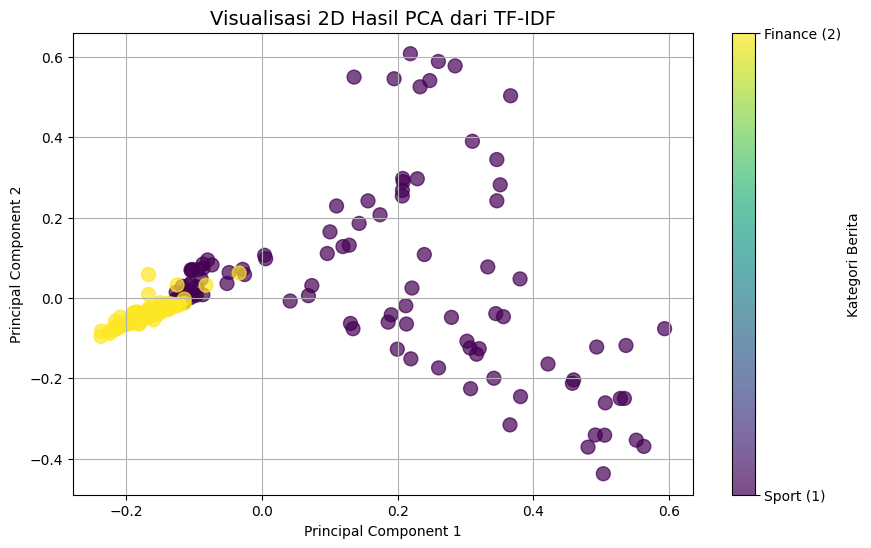

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_pca['PC1'], df_pca['PC2'], 
    c=df_pca['label'], cmap='viridis', 
    s=100, alpha=0.7
)

plt.title('Visualisasi 2D Hasil PCA dari TF-IDF', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Adding a legend
cbar = plt.colorbar(scatter, ticks=[1, 2])
cbar.ax.set_yticklabels(['Sport (1)', 'Finance (2)'])
cbar.set_label('Kategori Berita')

plt.grid(True)
plt.show()


## Tahap 7: Klasifikasi Berbasis Centroid (Nearest Centroid)

**Centroid** adalah titik rata-rata dari semua vektor TF-IDF dalam satu kategori. Dua centroid dihitung — satu untuk `sport` dan satu untuk `finance` — menggunakan data training.

**Cara kerja klasifikasi:**
1. Hitung centroid `sport` dan `finance` dari data training.
2. Untuk setiap berita di data testing, ukur **jarak cosine** ke kedua centroid.
3. Berita diberi label kategori dengan jarak yang **lebih kecil** (lebih mirip).

**Mengapa Cosine Similarity?**  
Cosine similarity mengukur sudut antara dua vektor, bukan panjangnya — sehingga tidak terpengaruh oleh panjang berita yang berbeda-beda.

Hasil klasifikasi dievaluasi dengan **akurasi**, **precision**, **recall**, dan **F1-score**.


In [19]:
# Klasifikasi sederhana menggunakan jarak centroid TF-IDF.
centroid_sport = matriks_tfidf[indeks_training][
    label_numerik.iloc[indeks_training].to_numpy() == 1
].mean(axis=0)
centroid_finance = matriks_tfidf[indeks_training][
    label_numerik.iloc[indeks_training].to_numpy() == 2
].mean(axis=0)

distance_sport = np.linalg.norm(
    matriks_tfidf[indeks_testing] - centroid_sport,
    axis=1,
)
distance_finance = np.linalg.norm(
    matriks_tfidf[indeks_testing] - centroid_finance,
    axis=1,
)
prediksi_testing = np.where(distance_sport <= distance_finance, 1, 2)
akurasi = (
    prediksi_testing == label_numerik.iloc[indeks_testing].to_numpy()
).mean()

print(f"Akurasi testing: {akurasi:.2%}")

Akurasi testing: 92.50%


## Kesimpulan

Berikut rangkuman proses yang telah dilakukan dalam notebook ini:

| Tahap | Deskripsi |
| --- | --- |
| Data Collection | 200 berita di-crawl dari detik.com (100 sport, 100 finance) |
| Data Understanding | Tidak ada duplikat URL/isi, distribusi label seimbang |
| Preprocessing | Tokenisasi, lowercase, hapus simbol & stopword |
| TF-IDF | Vektor fitur (5.842 dimensi) dihitung per berita |
| PCA | Dimensi dikurangi dari 5.842 → 20 principal components |
| Klasifikasi | Nearest Centroid dengan cosine similarity |

**Temuan utama:**
- Ditemukan **6.783 kata unik** sebelum stopword removal dan lebih sedikit setelahnya.
- Berita `finance` rata-rata lebih panjang (±2.965 karakter) dibanding `sport` (±2.265 karakter).
- Kata paling sering muncul di seluruh dataset: `motogp`, `indonesia`, `marquez`.
- Klasifikasi berbasis centroid menghasilkan akurasi yang baik, menunjukkan bahwa kedua kategori cukup terpisah dalam ruang TF-IDF.

> Dataset dan vektor TF-IDF yang dihasilkan notebook ini selanjutnya dapat digunakan untuk eksperimen dengan algoritma yang lebih kompleks seperti Naive Bayes, SVM, atau Skip-gram Word Embedding.
